# Chapter 5: 옵션 전략 — 실행 가능한 해설

이 노트북은 공식 ZIP을 체크섬으로 고정하고 정확 재현, 독립 실험, output-only 참조를 분리한다. 수익 숫자보다 데이터·시차·비용 계약을 먼저 읽는다.

In [1]:
from io import BytesIO
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
sys.path.insert(0, str(Path.cwd()))
import run_chapter5_analysis as ch5
data = ch5.load_data()
results = ch5.run_experiments(data)
checks = ch5.verify_results(data, results)
metrics = ch5.build_metrics(data, results, checks)
print(f"loaded: ETF={len(data.etf_dates)}, VX={len(data.vx_dates)}, checks={sum(checks.values())}/{len(checks)}")

loaded: ETF=2500, VX=2877, checks=22/22


## 1. 문제 정의와 학습 질문

실현변동성과 VXX는 같은가? 옵션 레버리지는 어디서 생기는가? 같은 시작·종가에서도 감마 스캘핑 손익은 왜 달라지는가? 원본 데이터가 빠졌을 때 무엇을 재현이라고 불러야 하는가?

In [2]:
def show_figure(fig):
    payload = BytesIO()
    fig.savefig(payload, format='png', dpi=120, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=payload.getvalue()))

pd.DataFrame(ch5.coverage_matrix())

,topic,status,evidence
0,realized-volatility versus VXX direction,exact source replay,bundled 20151125 ETF panel
1,XIV-SPY Kalman roll-return hedge,exact source replay,bundled VX and hedge-ratio MAT files
2,"Black-Scholes, Greeks, leverage, IV inversion",independent Python experiment,parity and finite-difference checks
3,gamma-scalping path and costs,conceptual synthetic experiment,"same endpoints, different paths"
4,SPY GARCH,overlap diagnostic + output-only reference,original input version absent
5,VX-SPY Kelly comparison,output-only reference,input version absent and source metric mixing
6,event-driven CL/LO options,code/output-only,licensed tick data unavailable
7,cross-sectional IV and dispersion,output-only reference,incomplete historical option panels


## 2. 재현 상태와 백테스트 범위

정확 재현은 두 경로뿐이다. 합성 감마 실험은 백테스트가 아님을 명시한다. 나머지 책 출력은 `compared:false + reason`이며 임의 숫자로 채우지 않는다.

재현 등급을 나누는 이유는 실행 가능한 MATLAB 파일이 곧 재현 가능한 연구 결과를 뜻하지 않기 때문이다. 소스가 외부의 특정 데이터 버전, 상용 틱, 저장되지 않은 중간 산출물을 읽으면 코드를 해석할 수는 있어도 최종 수치를 독립 검증할 수는 없다. 이 노트북은 그 경계를 표와 strict JSON 양쪽에 같은 용어로 남긴다.

In [3]:
pd.Series(metrics['reproduction_classification']).apply(lambda value: ', '.join(value))

exact_source_replay               compareVolWithVXX.m, XIV_SPY_rollreturn_lagged.m
independent_python_experiment    Black-Scholes and Greeks, synthetic gamma scal...
output_only_or_diagnostic        Kelly-scaled long SPY versus short VX, SPY GAR...
dtype: str

## 3. provenance와 environment versions

공식 URL, archive SHA-256, 40개 멤버 checksum, `uv.lock` SHA와 패키지 버전을 기록한다. offline 실행은 이 계약이 깨지면 즉시 실패한다.

In [4]:
pd.Series({**metrics['provenance'], 'uv_lock_sha256': metrics['environment']['uv_lock_sha256']})

source_page                                     https://epchan.com/book3
archive_url             https://epchan.com/img/book3/Chap5%20Options.zip
archive_sha256         3ffe46a1c8ed37e5611e114b02ab1a714efb676c9ecca2...
archive_size_bytes                                              41972176
member_count                                                          40
matlab_source_count                                                   30
research_data_count                                                   10
manifest_sha256        d5821b7661f3ea81ff6af680c3235aabd093f2f033b18f...
uv_lock_sha256         34057457773a614f058648f3ba9ba2f02f02354f64214e...
dtype: object

## 4. 데이터 구조와 결측 진단

ETF와 VX 패널의 날짜, 비양수 가격, missing 구조를 확인한다. 서로 다른 파일의 날짜 범위가 다르다는 사실이 곧 재현 가능 범위를 제한한다.

선물 행렬의 결측은 단순한 데이터 품질 문제가 아니다. 아직 상장되지 않았거나 이미 만기된 계약은 구조적으로 비어 있다. 따라서 임의 forward-fill을 하면 존재하지 않는 계약 가격을 만들어 롤 신호를 오염시킨다. 여기서는 각 열의 마지막 유효 관측으로 만기를 식별하고, 원본과 같은 30일~1일 창만 사용한다.

,rows,assets,date_start,date_end,missing_close,contracts_including_vix
etf,2500.0,26.0,20051221.0,20151125.0,3401.0,NaN
vx,2877.0,NaN,20040326.0,20150828.0,NaN,141.0


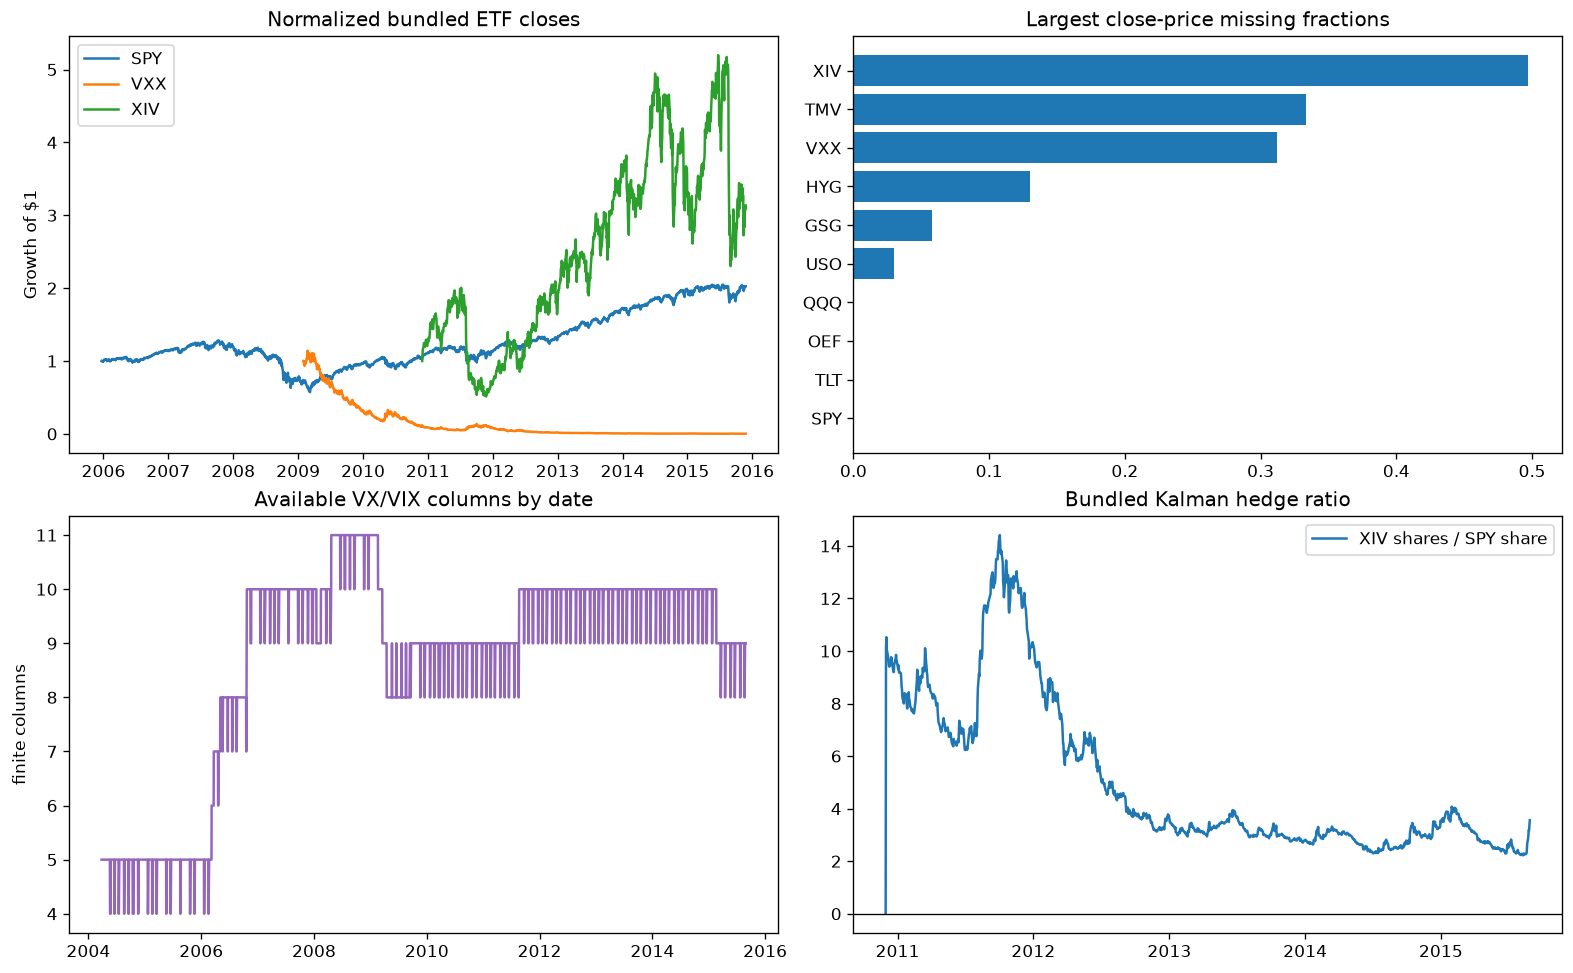

In [5]:
display(pd.DataFrame(metrics['data']).T)
show_figure(ch5.plot_data_diagnostics(data))

## 5. 구현 범위 coverage matrix

원본을 실행할 수 있다는 것과 원본 출력 숫자를 검증할 수 있다는 것은 다르다. 소스만 있고 라이선스 데이터가 없으면 code/output-only다.

In [6]:
pd.DataFrame(ch5.coverage_matrix())

,topic,status,evidence
0,realized-volatility versus VXX direction,exact source replay,bundled 20151125 ETF panel
1,XIV-SPY Kalman roll-return hedge,exact source replay,bundled VX and hedge-ratio MAT files
2,"Black-Scholes, Greeks, leverage, IV inversion",independent Python experiment,parity and finite-difference checks
3,gamma-scalping path and costs,conceptual synthetic experiment,"same endpoints, different paths"
4,SPY GARCH,overlap diagnostic + output-only reference,original input version absent
5,VX-SPY Kelly comparison,output-only reference,input version absent and source metric mixing
6,event-driven CL/LO options,code/output-only,licensed tick data unavailable
7,cross-sectional IV and dispersion,output-only reference,incomplete historical option panels


## 6. 실현변동성 변화와 VXX

책의 질문을 그대로 재현한다. 다음 비율이 50%보다 크게 낮다는 것은 두 방향이 자주 반대라는 뜻이지, 비용 없는 차익거래를 뜻하지 않는다.

SPY의 제곱 로그수익률은 실현변동성의 매우 짧고 잡음 많은 대용치다. 반면 VXX는 VIX 선물 포트폴리오의 가격이며 현물 VIX 자체도 아니다. 롤 수익률, 선물곡선의 콘탱고·백워데이션, 만기 교체가 함께 움직인다. 그러므로 방향 불일치를 발견한 뒤 곧바로 VXX를 반대로 매매하는 것은 경제적 연결고리를 건너뛴 해석이다.

In [7]:
pd.DataFrame(results['volatility_direction']['values'].items(), columns=['subset', 'same_direction_fraction'])

,subset,same_direction_fraction
0,all,0.350681
1,positive_spy,0.288420
2,negative_spy,0.426273


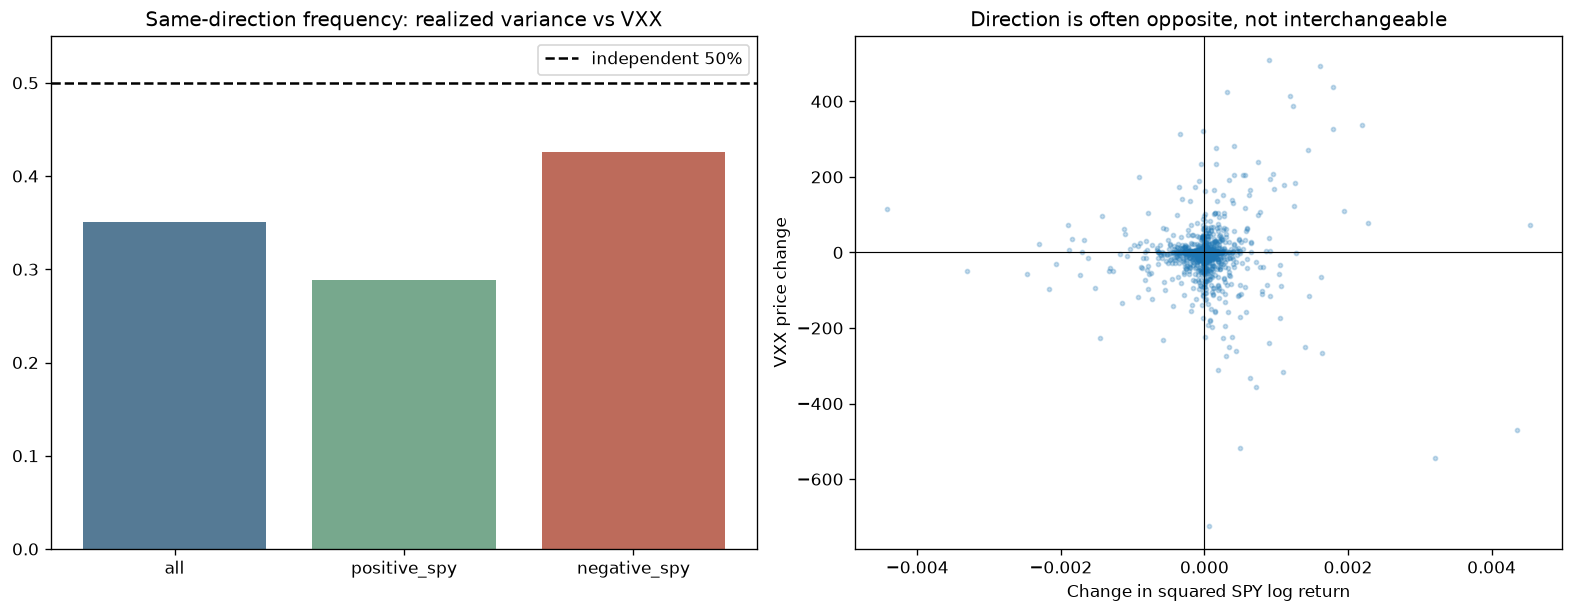

In [8]:
show_figure(ch5.plot_volatility_direction(results))

## 7. 수식 → 코드: Black–Scholes

$$C=S\Phi(d_1)-Ke^{-rT}\Phi(d_2).$$

`black_scholes()` 구현 함수는 가격과 Greeks를 반환하고 parity와 유한차분으로 검증된다.

In [9]:
theory = results['option_theory']
pd.Series({k:v for k,v in theory.items() if k not in {'strikes','call_leverage','put_leverage'}})

inputs                           {'spot': 100.0, 'strike': 100.0, 'tenor_years'...
call                                                                      2.939246
put                                                                       2.774997
call_delta                                                                0.523433
gamma                                                                     0.055566
parity_error                                                                   0.0
delta_finite_difference_error                                                 -0.0
gamma_finite_difference_error                                                 -0.0
recovered_sigma                                                               0.25
dtype: object

## 8. 내재변동성 역산

모형 가격에서 시작해 root solver로 sigma를 되찾는다. 실제 시장에서는 배당, 조기행사, 호가 비동기 때문에 이 검사가 충분조건은 아니다.

In [10]:
pd.Series({'true_sigma': theory['inputs']['sigma'], 'recovered_sigma': theory['recovered_sigma'], 'absolute_error': abs(theory['recovered_sigma']-theory['inputs']['sigma'])})

true_sigma         2.500000e-01
recovered_sigma    2.500000e-01
absolute_error     5.384582e-15
dtype: float64

## 9. 옵션 레버리지

델타 레버리지는 `delta × underlying value / option value`다. OTM에서 값이 커질 수 있지만 넓은 bid-ask와 낮은 체결 가능성을 무시하면 안 된다.

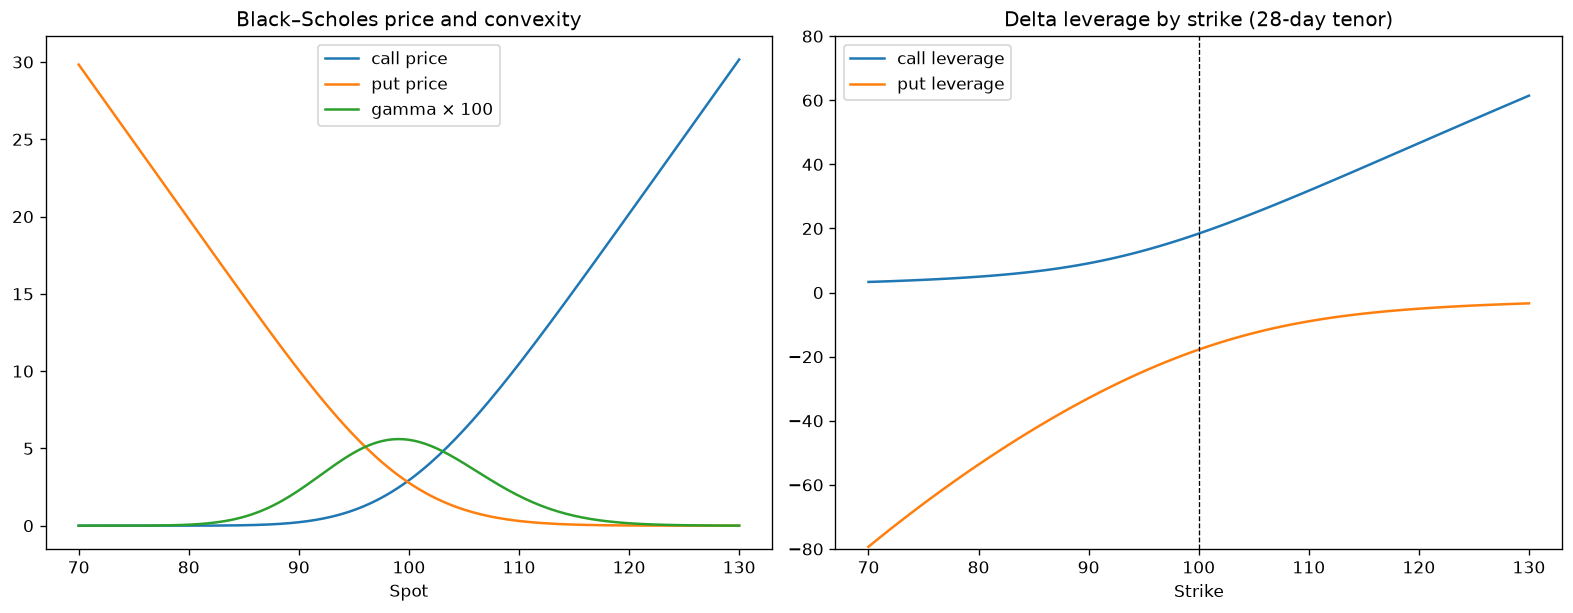

In [11]:
show_figure(ch5.plot_option_theory(results))

## 10. XIV–SPY 정확 재현

전일 VX/VIX로 롤 신호를 만들고 Kalman beta로 XIV와 SPY를 헤지한다. 포지션은 하루 지연해 적용하며 Sharpe·drawdown·Calmar를 원본과 비교한다.

분자는 직전 보유수량과 오늘 가격 변화의 곱이고, 분모는 직전 포지션의 총 절대 명목이다. 이 정규화는 XIV와 SPY의 가격 단위가 다른 문제를 줄이지만 증거금, 차입 가능성, ETF 조기상환 위험까지 반영하지는 않는다. XIV가 2018년에 청산된 사실처럼 상품 생존성은 역사적 백테스트의 외부 타당성을 제한한다.

annual_return             0.128078
sharpe                    1.101081
max_drawdown             -0.131693
max_drawdown_duration    18.000000
calmar                    0.972544
ending_return             0.764984
dtype: float64

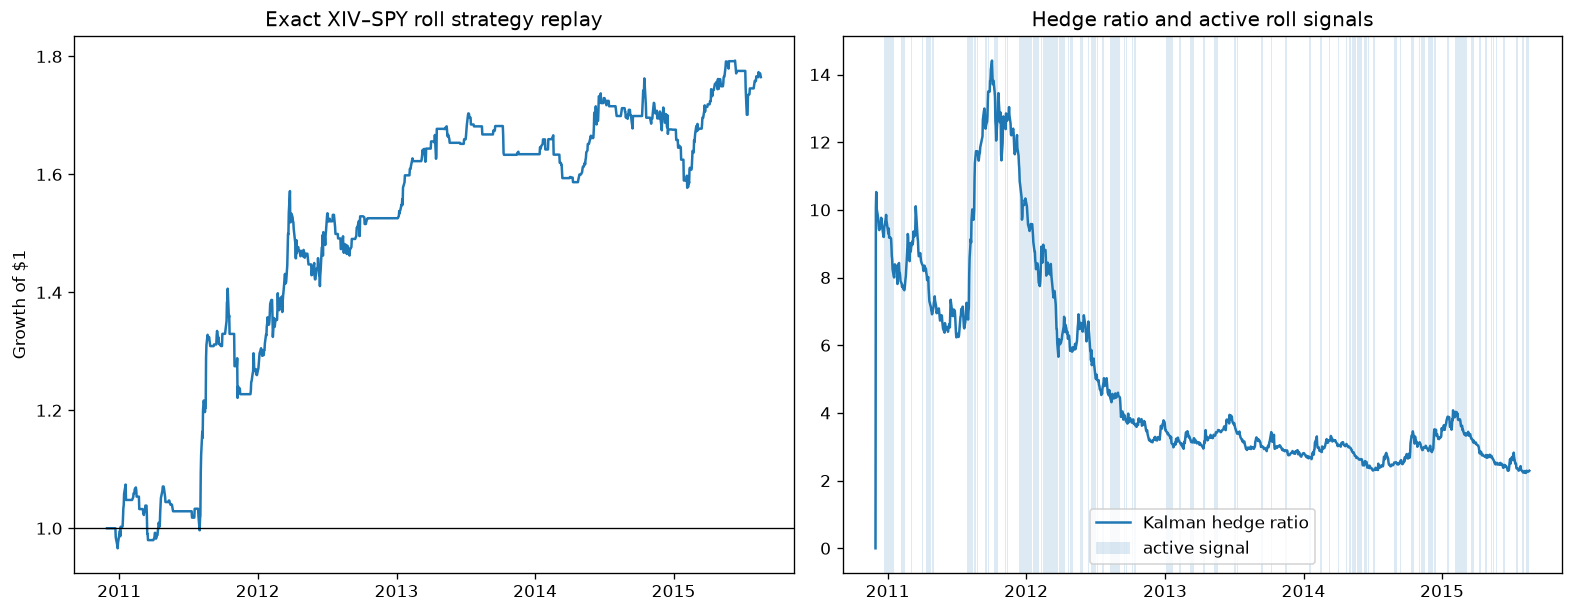

In [12]:
display(pd.Series(results['xiv_roll']['performance']))
show_figure(ch5.plot_xiv_roll(results))

## 11. look-ahead와 표본 외

신호의 관측시점, 포지션 적용시점, 훈련 구간을 분리한다. GARCH 저장 출력은 원 입력 버전이 빠져 있으므로 overlap diagnostic을 표본 외 정확 재현이라고 부르지 않는다.

In [13]:
pd.Series(results['forecast_overlap'])

dates           [20110908, 20110909, 20110912, 20110913, 20110...
accuracy                                                    0.598
observations                                                 1000
performance     {'annual_return': 0.7753532145515647, 'sharpe'...
compared                                                    False
reason          The archive omits inputDataOHLCDaily_ETF_20150...
dtype: object

## 12. 감마 스캘핑과 경로 의존성

같은 시작가와 종가라도 중간 진동이 다르면 델타 헤지 손익이 달라진다. 이는 옵션 최종 payoff만 보는 분석으로는 잡히지 않는다.

각 시점에는 직전 옵션 델타의 반대만큼 기초자산을 들고 다음 가격 변화까지 유지한다. 진동이 반복되면 양의 감마가 저가 매수·고가 매도의 재조정을 만들 수 있지만, 시간가치 감소와 헤지 비용이 그 이익을 상쇄한다. 두 경로는 수학적으로 만든 결정론적 배열이며 random seed = 20260718을 메타데이터에 고정한다. 난수를 쓰지 않는다는 사실도 재현 계약의 일부다.

In [14]:
pd.DataFrame(results['gamma_scalping']['pnl'])

,quiet,oscillating
0.0,-4.844641,-0.336462
1.0,-4.856907,-0.411885
5.0,-4.905972,-0.713579


## 13. 거래비용과 슬리피지

헤지 변경 명목에 0/1/5 bps를 부과한다. 옵션 bid-ask는 이보다 훨씬 클 수 있고, 책의 이벤트 전략도 진입·청산 주문 유형에 민감하다.

시장가 청산은 ask를 지불하고, 지정가 진입은 체결되지 않을 가능성을 감수한다. 중간가 체결을 항상 가정하면 실제로는 선택적으로 체결되는 주문을 모두 체결된 것처럼 만드는 낙관 편향이 생긴다. 따라서 비용 민감도 표는 수익성 증명이 아니라, 비용을 무시한 결과가 상한에 가깝다는 경고로 읽어야 한다.

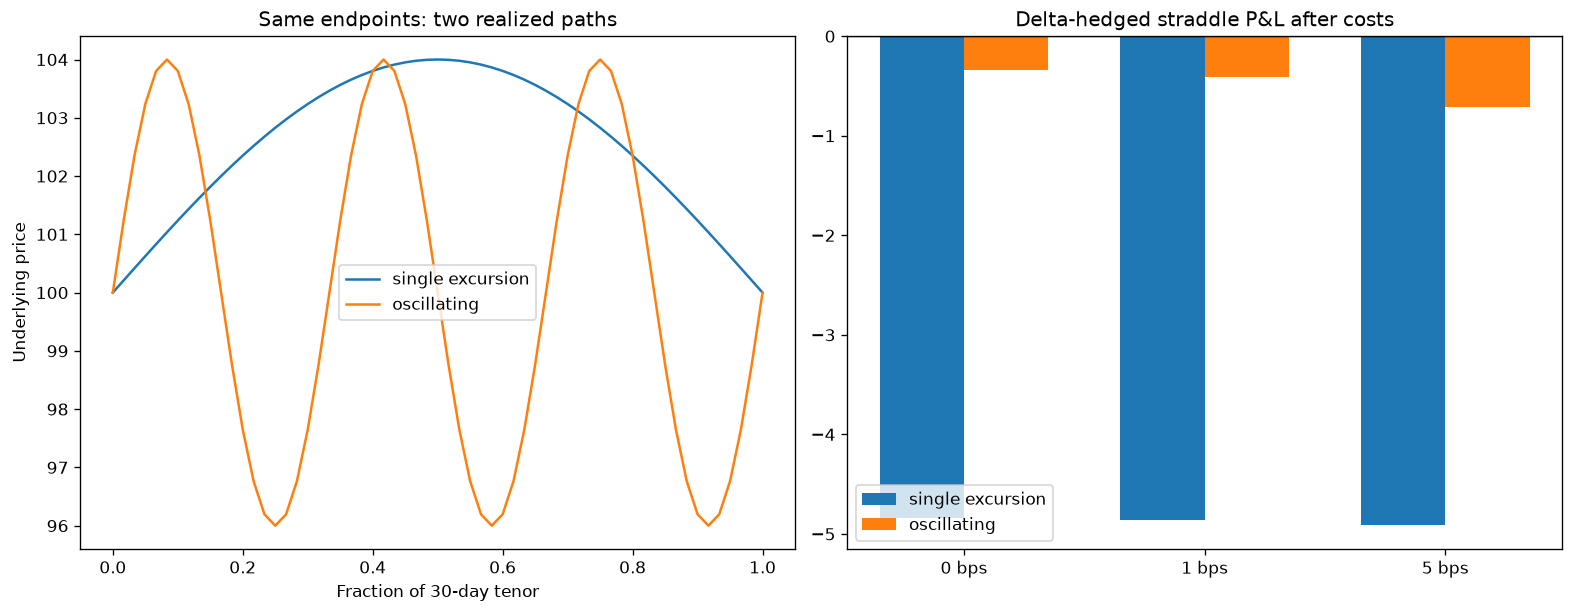

In [15]:
show_figure(ch5.plot_gamma_scalping(results))

## 14. 원본 MATLAB 비교

원본 6자리 주석은 반올림 반폭 `5e-7`로 비교한다. 완전 정밀도 Python 값, 원본 값, 절대오차를 strict JSON에 보존한다.

In [16]:
pd.DataFrame(metrics['book_comparisons'])

,strategy,metric,python,source,absolute_error,tolerance,matches_source
0,compareVolWithVXX.m,all,0.350681,0.350681,4.555645e-07,5.000000e-07,True
1,compareVolWithVXX.m,positive_spy,0.288420,0.288420,4.806992e-07,5.000000e-07,True
2,compareVolWithVXX.m,negative_spy,0.426273,0.426273,4.584450e-07,5.000000e-07,True
3,XIV_SPY_rollreturn_lagged.m,annual_return,0.128078,0.128078,4.976510e-07,5.000000e-07,True
4,XIV_SPY_rollreturn_lagged.m,sharpe,1.101081,1.101081,4.421488e-07,5.000000e-07,True
5,XIV_SPY_rollreturn_lagged.m,max_drawdown,-0.131693,-0.131693,2.781235e-07,5.000000e-07,True
6,XIV_SPY_rollreturn_lagged.m,calmar,0.972544,0.972544,3.895663e-08,5.000000e-07,True


## 15. output-only 결과와 데이터 라이선스

Nanex CL/LO 틱과 전체 Ivy 옵션 패널은 없다. 따라서 event, gamma, cross-sectional IV, dispersion 결과는 책값과 사유만 보존한다.

저장된 `dispersion_output.mat`과 `impVolCrossSectionalMeanReversion_output.mat`에는 포지션·Greek·일부 마지막 작업공간이 있지만, 각 거래일의 진입·청산 호가를 다시 연결할 전체 원천 파일은 없다. 중간 배열만으로 책의 P&L을 역산하면 미래에 저장된 상태나 최종 선택 결과를 입력으로 쓰는 순환 검증이 될 수 있다. 여기서는 MAT 파일이 존재한다는 사실을 데이터 완전성으로 오해하지 않고, 필요한 입력과 실제 포함 입력의 차이를 reason에 기록한다.

In [17]:
pd.DataFrame(metrics['reference_only_comparisons'])[['topic','compared','reason']]

,topic,compared,reason
0,Kelly-scaled long SPY versus short VX,False,The used ETF 20150828 panel is absent; the bun...
1,SPY GARCH volatility forecast,False,variance_SPY.mat was produced from the missing...
2,event-driven crude-oil straddles and strangles,False,The book and source say the licensed Nanex tic...
3,crude-oil gamma-scalping strangle,False,The official archive contains code but not the...
4,cross-sectional implied-volatility mean reversion,False,The output MAT preserves state arrays but not ...
5,dispersion trading,False,"The output MAT is a saved workspace state, not..."


## 16. 선택 편향·생존 편향 경고

행사가·만기·진입시각을 결과를 본 뒤 고르면 selection bias다. 주식 옵션 횡단면에는 survivorship bias와 상장폐지·기업행동도 있다.

특히 옵션은 한 기초자산마다 수많은 행사가와 만기를 동시에 제공하므로 자유도가 크다. 가장 좋은 tenor, moneyness, 이벤트 시각을 같은 표본에서 고르고 평가하면 다중검정 문제가 급격히 커진다. 시간순 walk-forward 또는 완전히 격리된 표본 외 기간이 필요하며, 그 전까지 높은 Sharpe는 탐색 결과로 취급한다.

## 17. 자동 verification

검사는 수치 일치뿐 아니라 시차, 거래비용 단조성, 데이터 누락 공개, synthetic 실험의 범위까지 확인한다. 하나의 총점만 보지 않고 독립 수치 검사와 설계 invariant를 따로 센다. 실패 목록은 metrics에 남아 노트북 셀의 성공 여부와 별개로 기계 판독할 수 있다.

In [18]:
verification = pd.Series(checks, name='passed')
display(verification)
assert verification.all()
print(f"verification passed: {verification.sum()}/{len(verification)}")

archive_manifest_matches                           True
all_40_archive_members_pinned                      True
thirty_matlab_sources_present                      True
etf_dates_are_strictly_increasing                  True
vx_dates_are_strictly_increasing                   True
volatility_direction_matches_source                True
xiv_roll_metrics_match_source                      True
xiv_roll_positions_are_lagged                      True
xiv_roll_signal_uses_previous_day_prices           True
put_call_parity_holds                              True
delta_matches_finite_difference                    True
gamma_matches_finite_difference                    True
implied_volatility_is_recovered                    True
option_leverage_is_finite                          True
gamma_paths_share_endpoints                        True
gamma_scalping_is_path_dependent                   True
transaction_costs_do_not_improve_gamma_scalping    True
forecast_overlap_is_not_claimed_exact           

verification passed: 22/22


## 18. 결론

옵션 전략의 품질은 화려한 CAGR보다 입력 버전, 체결 가정, 레버리지 정의와 재현 상태를 얼마나 정직하게 분리했는지에서 결정된다.

이 장에서 실제로 재사용할 수 있는 것은 특정 수익률보다 검증 순서다. 먼저 원본 입력과 날짜를 고정하고, 신호와 체결 시점을 분리하며, 가격·Greek의 수학적 항등식을 독립 검사한다. 그 다음 비용과 꼬리 위험을 넣고, 마지막에만 성과지표를 읽는다. 입력이 빠진 결과는 책값을 보존하되 비교하지 않는다. 이 원칙은 다른 옵션 시장과 다른 교재에도 그대로 적용된다.